# Import

In [1]:
import numpy as np # For linear algebra
import pandas as pd # For reading data (csv file) and creating data frame
import matplotlib.pyplot as plt # For plotting chart
import seaborn as sns # For data visualization
import plotly.express as px # For visualizing 3d plots

# Getting File Path

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fifa-24-player-stats-dataset/player_stats.csv


# Getting Data

In [3]:
df = pd.read_csv('/kaggle/input/fifa-24-player-stats-dataset/player_stats.csv', encoding='ISO-8859-1')

**COLUMNS DESCRIPTION**

- Player: The name of the football player.
- Country: The nationality or home country of the player.
- Height: The height of the player in centimeters.
- Weight: The weight of the player in kilograms.
- Age: The age of the player.
- Club: The club to which the player is currently affiliated.
- Ball Control: Player's skill in controlling the ball.
- Dribbling: Player's dribbling ability.
- Marking: Player's marking skill.
- Slide Tackle: Player's ability to perform slide tackles.
- Stand Tackle: Player's ability to perform standing tackles.
- Aggression: Player's aggression level.
- Reactions: Player's reaction time.
- Attacking Position: Player's positioning for attacking plays.
- Interceptions: Player's skill in intercepting passes.
- Vision: Player's vision on the field.
- Composure: Player's composure under pressure.
- Crossing: Player's ability to deliver crosses.
- Short Pass: Player's short passing accuracy.
- Long Pass: Player's ability in long passing.
- Acceleration: Player's acceleration on the field.
- Stamina: Player's stamina level.
- Strength: Player's physical strength.
- Balance: Player's balance while playing.
- Sprint Speed: Player's speed in sprints.
- Agility: Player's agility in maneuvering.
- Jumping: Player's jumping ability.
- Heading: Player's heading skills.
- Shot Power: Player's power in shooting.
- Finishing: Player's finishing skills.
- Long Shots: Player's ability to make long-range shots.
- Curve: Player's ability to curve the ball.
- Free Kick Accuracy: Player's accuracy in free-kick situations.
- Penalties: Player's penalty-taking skills.
- Volleys: Player's volleying skills.
- Goalkeeper Positioning: Goalkeeper's positioning attribute (specific to goalkeepers).
- Goalkeeper Diving: Goalkeeper's diving ability (specific to goalkeepers).
- Goalkeeper Handling: Goalkeeper's ball-handling skill (specific to goalkeepers).
- Goalkeeper Kicking: Goalkeeper's kicking ability (specific to goalkeepers).
- Goalkeeper Reflexes: Goalkeeper's reflexes (specific to goalkeepers).
- Value: The estimated value of the player.

# Exploring Data Frame

In [4]:
# getting first 5 rows of data
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [5]:
# information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [6]:
print(f'Number of rows : {df.shape[0]}')
print(f'Number of cols : {df.shape[1]}')

Number of rows : 5682
Number of cols : 41


In [7]:
# Function to remove '$' and '.' from string
def f(x):
    return float(x.replace('$','').replace('.',''))

In [8]:
f('1.400.00')

140000.0

In [9]:
# As value is a numerical col but because of $ and commas pandas is treating it as object
# let's convert it to float
df['value'] = np.vectorize(f)(df['value'])

In [10]:
# let's get categorical col
cat_col = df.select_dtypes(include='object').columns

In [11]:
# numerical col
num_col = df.drop(cat_col, axis=1).columns

In [12]:
cat_col

Index(['player', 'country', 'club'], dtype='object')

In [13]:
num_col

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking',
       'slide_tackle', 'stand_tackle', 'aggression', 'reactions',
       'att_position', 'interceptions', 'vision', 'composure', 'crossing',
       'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength',
       'balance', 'sprint_speed', 'agility', 'jumping', 'heading',
       'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties',
       'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

In [14]:
for col in cat_col:
    print(f'Number Of Unique Value in {col} : {df[col].nunique()}')

Number Of Unique Value in player : 5657
Number Of Unique Value in country : 135
Number Of Unique Value in club : 689


In [15]:
# let's get five number summary for numerical cols
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
height,5682.0,1.816705e+02,6.829238e+00,156.0,177.0,182.0,186.0,204.0
weight,5682.0,7.528229e+01,6.998971e+00,54.0,70.0,75.0,80.0,102.0
age,5682.0,2.631626e+01,4.729967e+00,17.0,23.0,26.0,30.0,41.0
ball_control,5682.0,5.891218e+01,1.656707e+01,8.0,55.0,63.0,69.0,94.0
dribbling,5682.0,5.612848e+01,1.877208e+01,5.0,51.0,62.0,68.0,95.0
marking,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slide_tackle,5682.0,4.672844e+01,2.051943e+01,7.0,27.0,54.0,64.0,87.0
stand_tackle,5682.0,4.882084e+01,2.097597e+01,7.0,30.0,57.0,66.0,91.0
aggression,5682.0,5.632401e+01,1.684641e+01,11.0,45.0,60.0,69.0,96.0
reactions,5682.0,6.195935e+01,8.893309e+00,32.0,56.0,62.0,68.0,93.0


In [16]:
# let's see if there any duplicated rows present in the data frame
df.duplicated().sum()

3

In [17]:
# as there are three duplicated rows present let's see them
df[df.duplicated()]

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
158,Maxime CrÃ©peau,Canada,180,88,29,LAFC,45,19,NaN,17,...,16,14,23,19,70,72,70,70,75,2200000.0
159,Stefan Thesker,Germany,190,84,32,Holstein Kiel,55,45,NaN,64,...,33,31,42,40,14,13,7,10,12,70000.0
160,Cameron John,England,181,78,24,Rochdale,55,53,NaN,57,...,34,25,32,28,8,13,9,7,8,35000.0


In [18]:
# let's remove these duplicated rows from the data frame
df = df.drop_duplicates()

In [19]:
# let's see if there null values present in the data frame
df.isnull().sum()

player               0
country              0
height               0
weight               0
age                  0
club                 0
ball_control         0
dribbling            0
marking           5679
slide_tackle         0
stand_tackle         0
aggression           0
reactions            0
att_position         0
interceptions        0
vision               0
composure            0
crossing             0
short_pass           0
long_pass            0
acceleration         0
stamina              0
strength             0
balance              0
sprint_speed         0
agility              0
jumping              0
heading              0
shot_power           0
finishing            0
long_shots           0
curve                0
fk_acc               0
penalties            0
volleys              0
gk_positioning       0
gk_diving            0
gk_handling          0
gk_kicking           0
gk_reflexes          0
value                0
dtype: int64

In [20]:
# as this column is completely empty let's drop this column from the data frame
df = df.drop('marking', axis=1)

In [21]:
num_col = df.drop(cat_col, axis=1).columns

In [22]:
df.isnull().sum()

player            0
country           0
height            0
weight            0
age               0
club              0
ball_control      0
dribbling         0
slide_tackle      0
stand_tackle      0
aggression        0
reactions         0
att_position      0
interceptions     0
vision            0
composure         0
crossing          0
short_pass        0
long_pass         0
acceleration      0
stamina           0
strength          0
balance           0
sprint_speed      0
agility           0
jumping           0
heading           0
shot_power        0
finishing         0
long_shots        0
curve             0
fk_acc            0
penalties         0
volleys           0
gk_positioning    0
gk_diving         0
gk_handling       0
gk_kicking        0
gk_reflexes       0
value             0
dtype: int64

# Data Visualization

**UNIVARIATE ANALYSIS**

In [23]:
#let's visualize top 10 clubs
club_df = df['club'].value_counts().reset_index()[:10]

In [24]:
club_df

,club,count
0,River Plate,21
1,Liverpool,17
2,LanÃºs,17
3,Barnsley,16
4,Girona FC,16
5,Arsenal,16
6,Jeonbuk Hyundai,15
7,VfB Stuttgart,15
8,Valencia CF,15
9,CÃ¡diz CF,15


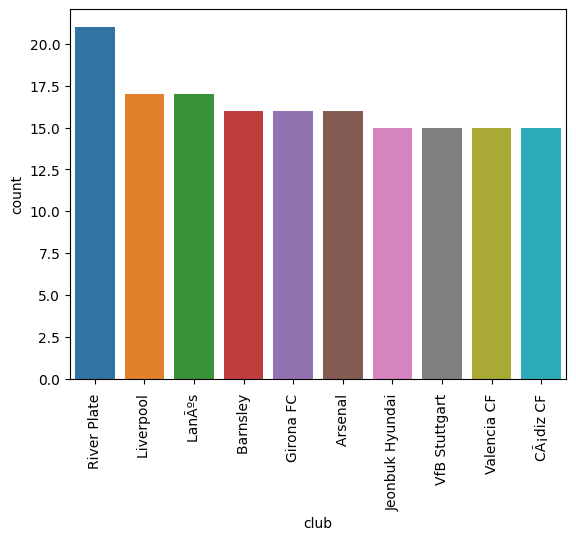

In [25]:
plt.figure(dpi=100)
sns.barplot(data=club_df,x='club',y='count')
plt.xticks(rotation=90);

In [26]:
# let's visulize top 10 country to which players belong
country_df = df['country'].value_counts().reset_index()[:10]

In [27]:
country_df

,country,count
0,England,515
1,Germany,389
2,Spain,356
3,France,309
4,Argentina,302
5,Brazil,223
6,Italy,186
7,Netherlands,146
8,Sweden,124
9,Republic of Ireland,121


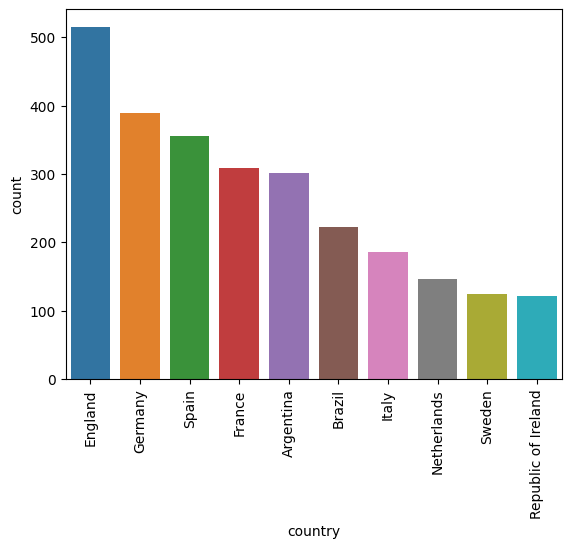

In [28]:
plt.figure(dpi=100)
sns.barplot(data=country_df,x='country',y='count')
plt.xticks(rotation=90);

In [29]:
num_col

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle',
       'stand_tackle', 'aggression', 'reactions', 'att_position',
       'interceptions', 'vision', 'composure', 'crossing', 'short_pass',
       'long_pass', 'acceleration', 'stamina', 'strength', 'balance',
       'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power',
       'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys',
       'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

<Axes: xlabel='height', ylabel='Count'>

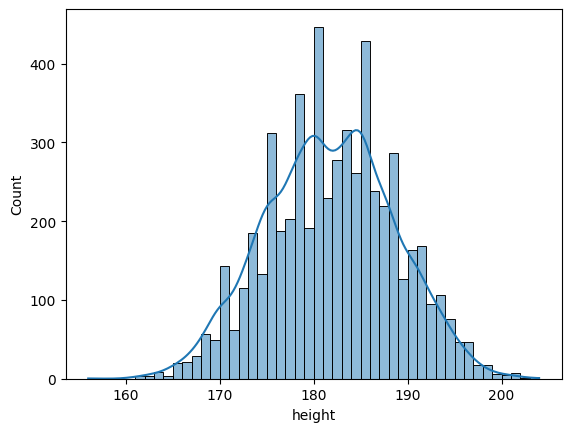

In [30]:
#let's visualize distribution of height of the players
plt.figure(dpi=100)
sns.histplot(data=df,x='height',kde=True)
# most player have height around 185 cms

<Axes: xlabel='height'>

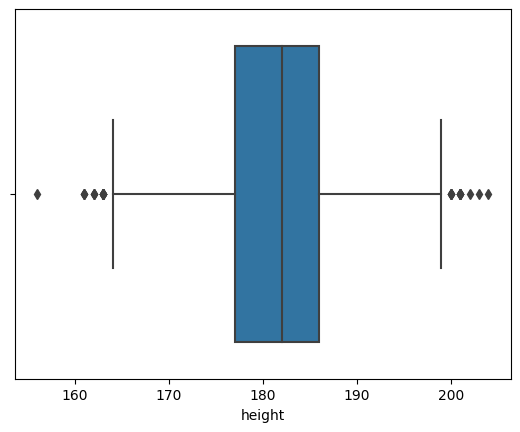

In [31]:
# let's get outliers using box plot
sns.boxplot(data=df,x='height')

In [32]:
# there is one player with very less height compared to other let's get that player
df[df['height']<160]

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
5474,Carlos MÃ©ndez,Venezuela,156,55,19,Dep. TÃ¡chira,52,50,56,58,...,38,37,46,32,8,13,9,14,13,13000.0


<Axes: xlabel='weight', ylabel='Count'>

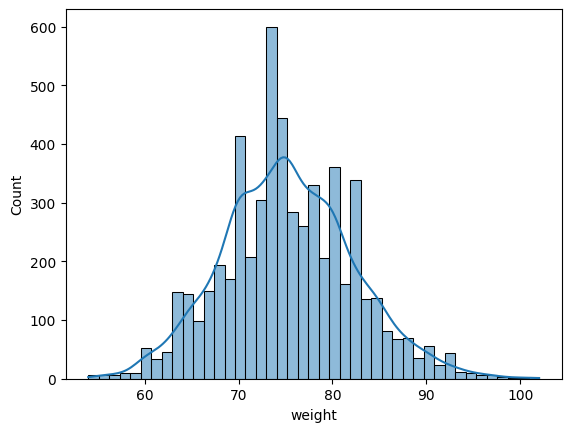

In [33]:
# let's visualize weight distribution of players
plt.figure(dpi=100)
sns.histplot(data=df,x='weight',kde=True)
# most of the players have weight in range 70-80

<Axes: xlabel='weight'>

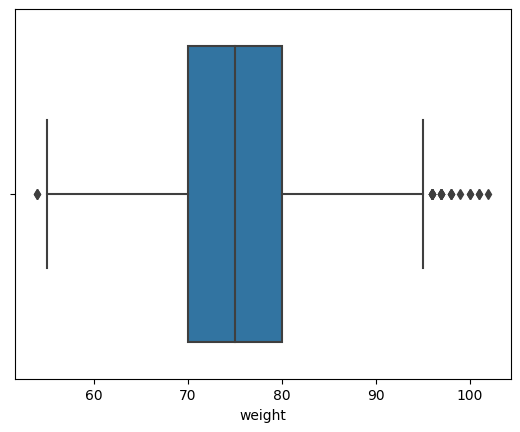

In [34]:
# let's visualize outliers 
sns.boxplot(data=df,x='weight')

<Axes: xlabel='age', ylabel='Count'>

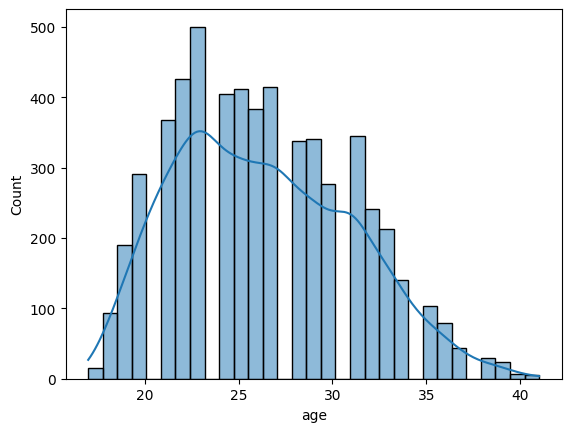

In [35]:
# let's visualize age distribution
plt.figure(dpi=100)
sns.histplot(data=df,x='age',kde=True)

<Axes: xlabel='age'>

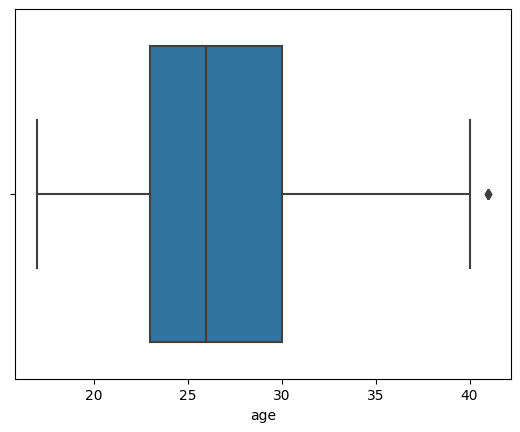

In [36]:
# let's visualize outliers
sns.boxplot(data=df,x='age')

In [37]:
# thers seem to be some player with highest age as outlier let's get this player
df[df['age']==df['age'].max()]

,player,country,height,weight,age,club,ball_control,dribbling,slide_tackle,stand_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
1574,AntolÃ­n AlcÃ¡raz,Paraguay,187,78,41,Olimpia,61,57,73,74,...,32,35,48,35,16,8,11,10,11,32500.0
3930,Pepe Reina,Spain,188,92,41,Villarreal CF,23,10,24,22,...,11,11,24,11,79,75,77,79,76,27500.0
4422,Diego LÃ³pez,Spain,196,89,41,Rayo Vallecano,25,11,14,13,...,10,11,21,14,80,76,78,68,76,45000.0
5409,Enrique Bologna,Argentina,189,87,41,Defensa,32,22,17,22,...,16,18,25,10,70,73,66,71,73,5000.0
5681,Zlatan Ibrahimovi?,Sweden,195,102,41,Milan,85,75,24,37,...,79,74,80,87,9,13,15,10,12,10500000.0


**BIVARIATE ANALYSIS**

In [38]:
num_col

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'slide_tackle',
       'stand_tackle', 'aggression', 'reactions', 'att_position',
       'interceptions', 'vision', 'composure', 'crossing', 'short_pass',
       'long_pass', 'acceleration', 'stamina', 'strength', 'balance',
       'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power',
       'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys',
       'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes', 'value'],
      dtype='object')

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


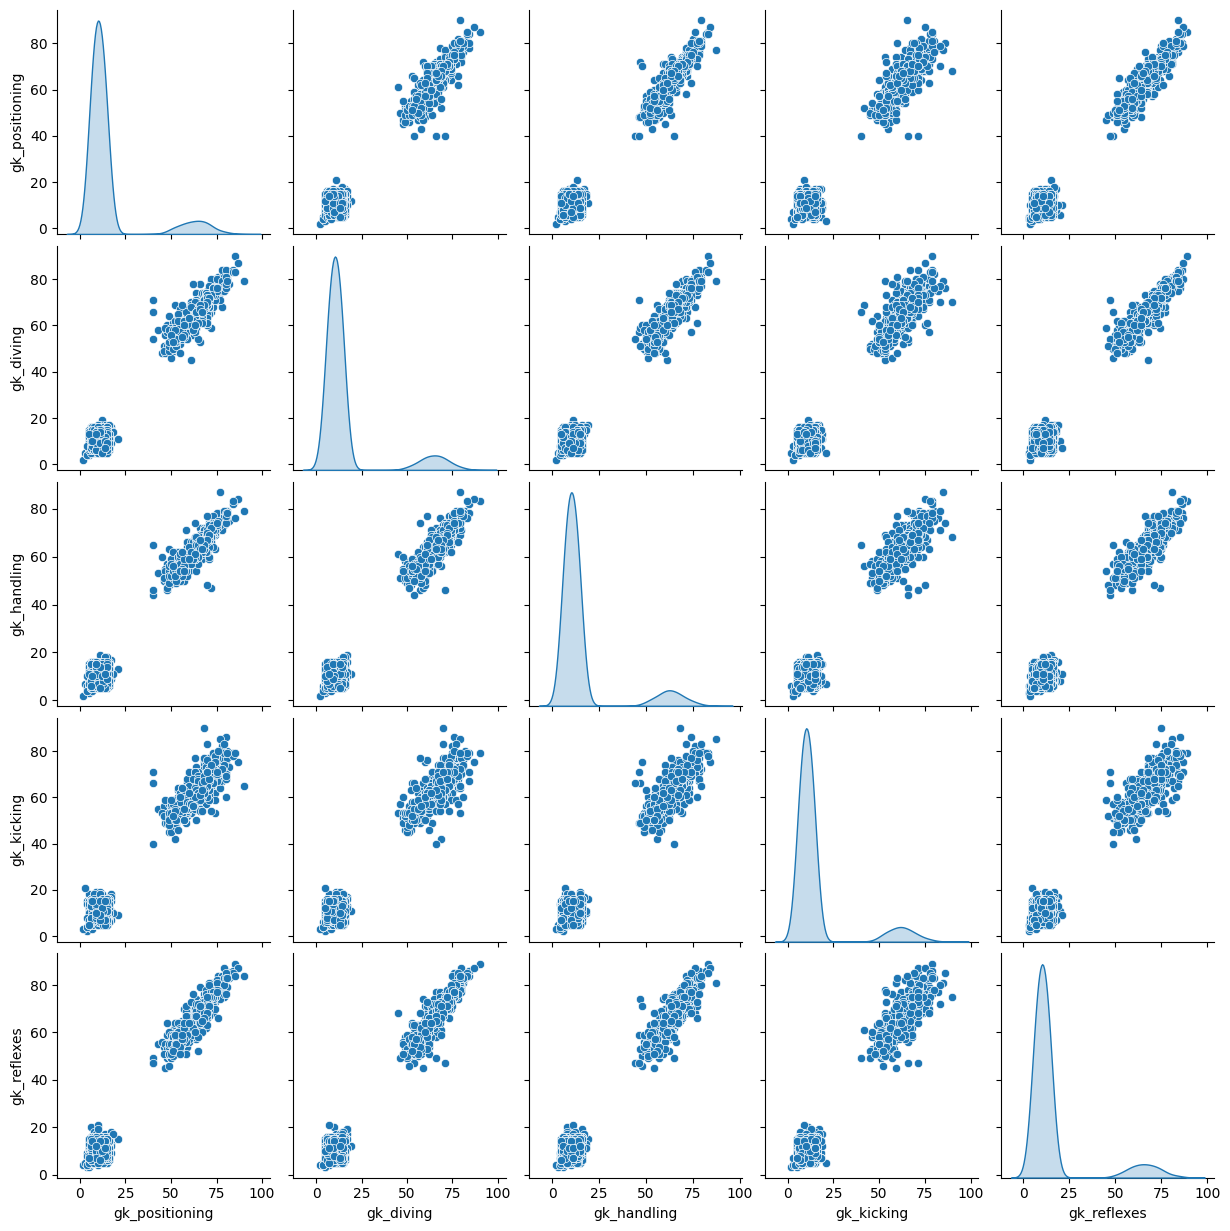

In [39]:
sns.pairplot(data=df[['gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes']], diag_kind='kde')
# we can see these 5 colums seems to be quite related to each other

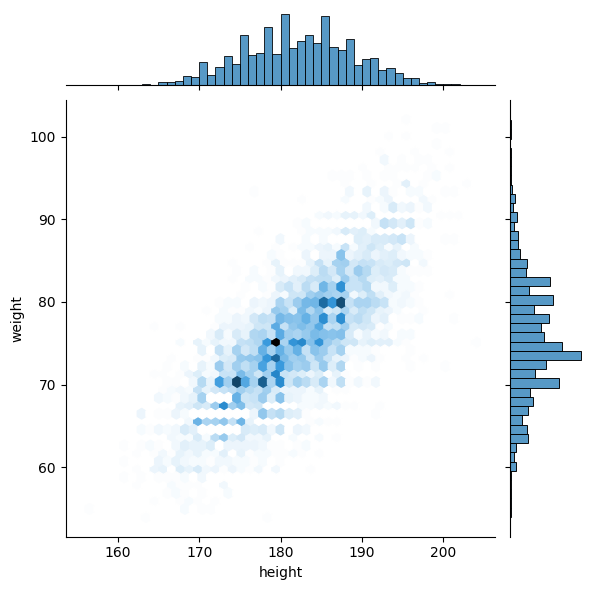

In [40]:
sns.jointplot(data=df,x='height',y='weight',kind='hex')

<Axes: xlabel='aggression', ylabel='heading'>

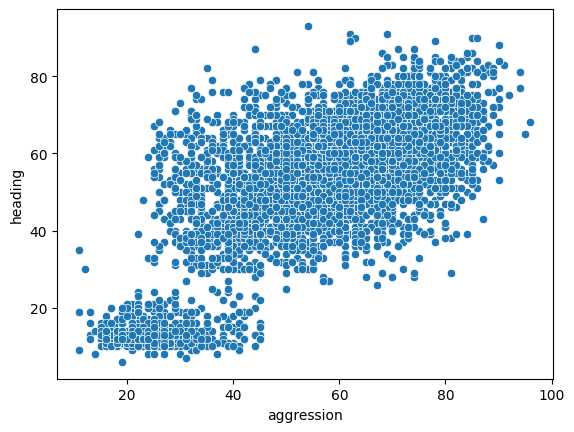

In [41]:
# players with more agression seem to have more heading skill
sns.scatterplot(data=df,x='aggression',y='heading')

**MULTIVARIATE ANALYSIS**

In [42]:
# let's visualize 'slide_tackle', 'stand_tackle' and 'interceptions'
# these three seem to be correlated with each other
# color represent the value of the player
fig = px.scatter_3d(df, x='slide_tackle', y='stand_tackle', z='interceptions',
              color='value')
fig.show()

In [43]:
# here visualizing 'long_pass', 'short_pass' and 'stamina' of the players
# we can see players with high value of these variables seem to be earning more
fig = px.scatter_3d(df, x='long_pass', y='short_pass', z='stamina',
              color='value')
fig.show()

In [44]:
fig = px.scatter_3d(df, x='crossing', y='ball_control', z='dribbling',
              color='value')
fig.show()

In [45]:
#let's visualize weight, height and age in 3d plot
fig = px.scatter_3d(df, x='weight', y='height', z='age',
              color='value')
fig.show()

<Axes: >

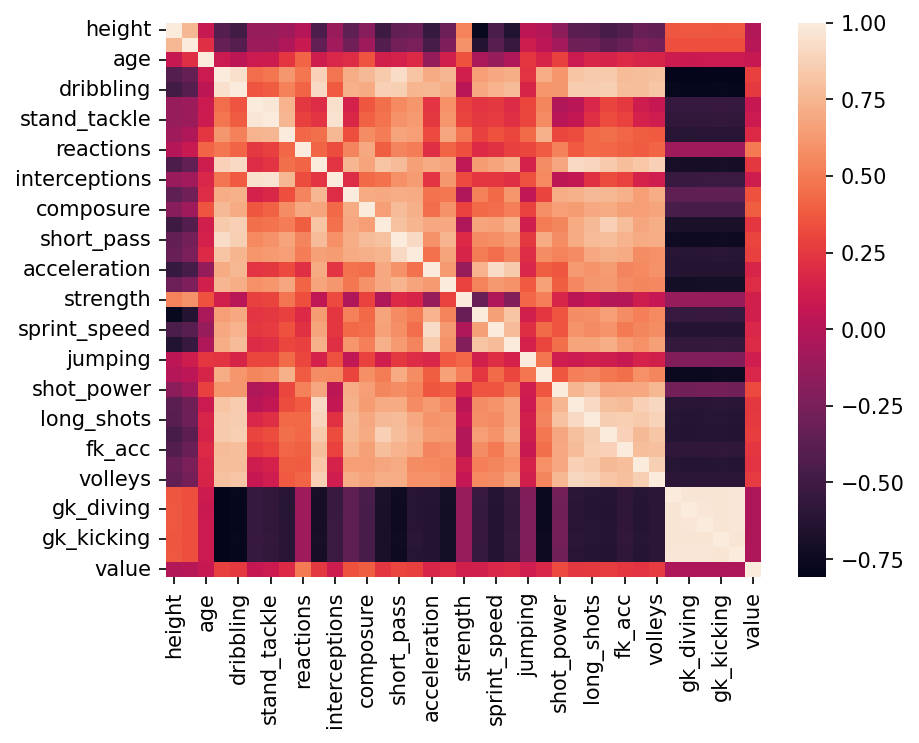

In [46]:
plt.figure(dpi=150)
sns.heatmap(df[num_col].corr())

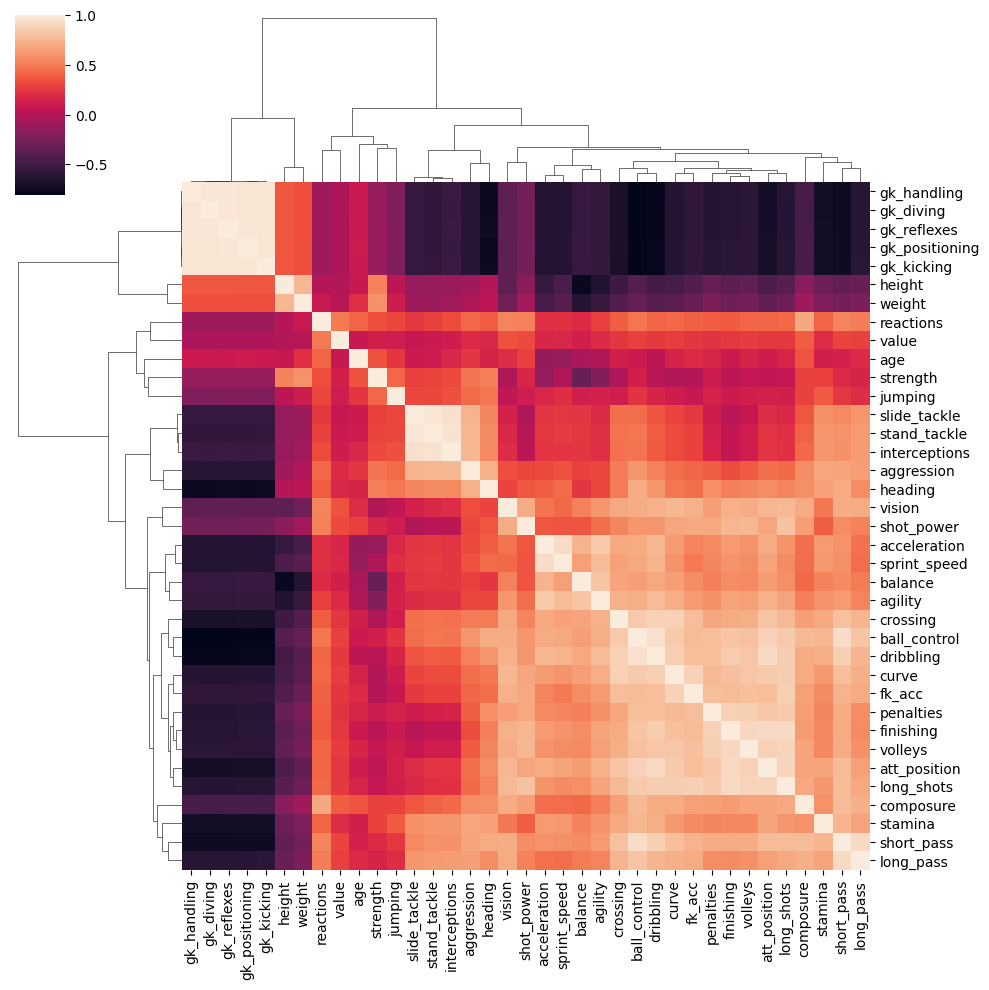

In [47]:
sns.clustermap(df[num_col].corr())